Part 1: Data Loading & Exploration

In [3]:
# ==========================================
# AI Resume Screening & Candidate Ranking
# Future Interns - ML Task 3
# Author: Shashikant Jha
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Text Processing
import re
import string

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Resume.zip to Resume.zip


In [5]:
import zipfile

with zipfile.ZipFile("Resume.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
df = pd.read_csv("Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [7]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 2484
Columns : 4


In [8]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [11]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [12]:
df = df.dropna()

print(df.shape)

(2484, 4)


In [13]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [14]:
df["Category"].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


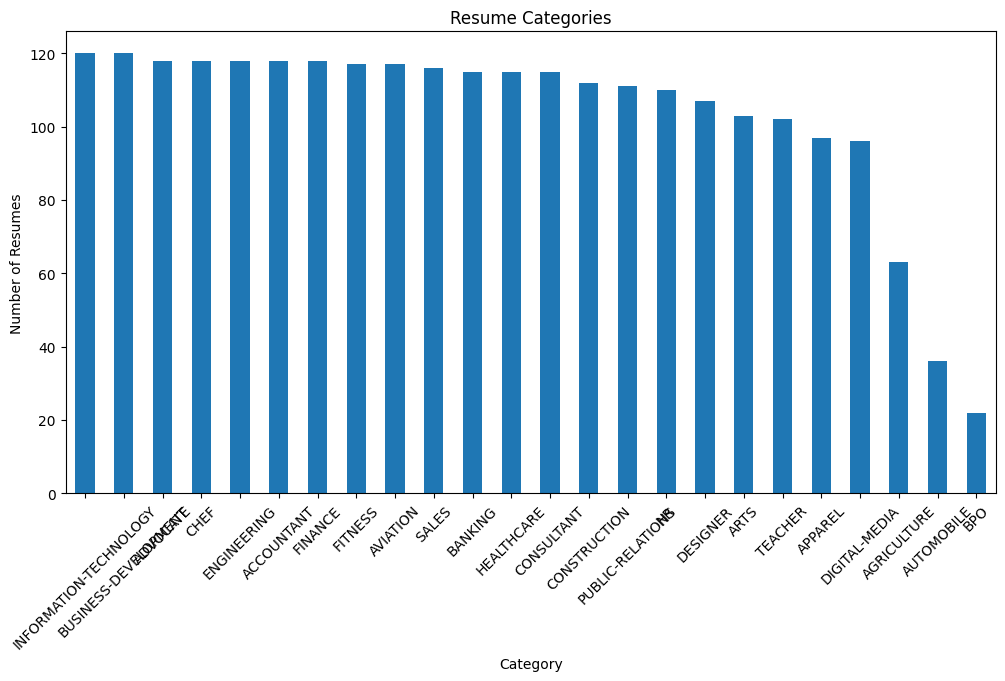

In [15]:
plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Categories")

plt.xlabel("Category")

plt.ylabel("Number of Resumes")

plt.xticks(rotation=45)

plt.show()

In [18]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [19]:
print(df["Resume_str"][0])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss preve

In [21]:
df["Resume_Length"] = df["Resume_str"].apply(len)

df["Resume_Length"].describe()

,Resume_Length
count,2484.000000
mean,6295.308776
std,2769.251458
min,21.000000
25%,5160.000000
50%,5886.500000
75%,7227.250000
max,38842.000000


Part 2: Text Cleaning & NLP Preprocessing

In [23]:
df = df[["ID", "Category", "Resume_str"]]

df.head()

,ID,Category,Resume_str
0,16852973,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,22323967,HR,"HR SPECIALIST, US HR OPERATIONS ..."
2,33176873,HR,HR DIRECTOR Summary Over 2...
3,27018550,HR,HR SPECIALIST Summary Dedica...
4,17812897,HR,HR MANAGER Skill Highlights ...


In [24]:
df.isnull().sum()

,0
ID,0
Category,0
Resume_str,0


In [25]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (2484, 3)
After: (2484, 3)


In [26]:
df["Resume_str"] = df["Resume_str"].str.lower()

df.head()

,ID,Category,Resume_str
0,16852973,HR,hr administrator/marketing associate\...
1,22323967,HR,"hr specialist, us hr operations ..."
2,33176873,HR,hr director summary over 2...
3,27018550,HR,hr specialist summary dedica...
4,17812897,HR,hr manager skill highlights ...


In [27]:
import string

df["Resume_str"] = df["Resume_str"].str.translate(
    str.maketrans("", "", string.punctuation)
)

In [28]:
import re

df["Resume_str"] = df["Resume_str"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

In [29]:
df["Resume_str"] = df["Resume_str"].str.strip()

In [30]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [31]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [32]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [33]:
def clean_resume(text):

    words = text.split()

    cleaned = []

    for word in words:

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            cleaned.append(word)

    return " ".join(cleaned)

In [34]:
df["Clean_Resume"] = df["Resume_str"].apply(clean_resume)

df.head()

,ID,Category,Resume_str,Clean_Resume
0,16852973,HR,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...
1,22323967,HR,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...
2,33176873,HR,hr director summary over years exp...,hr director summary year experience recruiting...
3,27018550,HR,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...
4,17812897,HR,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...


In [35]:
comparison = pd.DataFrame({

    "Original Resume": df["Resume_str"].head(),

    "Cleaned Resume": df["Clean_Resume"].head()

})

comparison

,Original Resume,Cleaned Resume
0,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...
1,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...
2,hr director summary over years exp...,hr director summary year experience recruiting...
3,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...
4,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...


In [36]:
df = df[df["Clean_Resume"] != ""]

In [37]:
df.head()

,ID,Category,Resume_str,Clean_Resume
0,16852973,HR,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...
1,22323967,HR,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...
2,33176873,HR,hr director summary over years exp...,hr director summary year experience recruiting...
3,27018550,HR,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...
4,17812897,HR,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...


Part 3: Feature Engineering & Resume Matching

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
job_description = """
AI Engineer

Required Skills:
Python
Machine Learning
Deep Learning
TensorFlow
PyTorch
SQL
Pandas
NumPy
Scikit-learn
Git
Data Analysis
Problem Solving
Communication
"""

In [40]:
print(job_description)


AI Engineer

Required Skills:
Python
Machine Learning
Deep Learning
TensorFlow
PyTorch
SQL
Pandas
NumPy
Scikit-learn
Git
Data Analysis
Problem Solving
Communication



In [41]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [42]:
documents = [job_description] + df["Clean_Resume"].tolist()

In [43]:
tfidf_matrix = tfidf.fit_transform(documents)

print(tfidf_matrix.shape)

(2484, 5000)


In [44]:
job_vector = tfidf_matrix[0]

resume_vectors = tfidf_matrix[1:]

In [45]:
similarity_scores = cosine_similarity(
    job_vector,
    resume_vectors
)

In [46]:
df["Match Score"] = (
    similarity_scores.flatten() * 100
).round(2)

In [47]:
df[["Category", "Match Score"]].head()

,Category,Match Score
0,HR,1.55
1,HR,2.46
2,HR,0.00
3,HR,0.29
4,HR,0.96


In [48]:
ranking = df.sort_values(
    by="Match Score",
    ascending=False
)

ranking.head(10)

,ID,Category,Resume_str,Clean_Resume,Match Score
1762,12011623,ENGINEERING,engineering and quality technician caree...,engineering quality technician career overview...,20.98
2153,34953092,BANKING,corporate banking assistant intern o...,corporate banking assistant intern objective d...,20.83
2293,26069113,ARTS,software engineer profile experience...,software engineer profile experienced software...,18.78
2291,12777487,ARTS,online learning coordinator program training ...,online learning coordinator program training s...,18.32
1218,21156767,CONSULTANT,pavithra shetty summary custome...,pavithra shetty summary customeroriented princ...,18.01
194,18835363,DESIGNER,program manager designer professional...,program manager designer professional summary ...,17.38
1339,18448085,AUTOMOBILE,data analyst professional summary ind...,data analyst professional summary industrial s...,16.21
1142,30863060,CONSULTANT,consultant summary college graduate w...,consultant summary college graduate interest i...,15.93
1348,22946204,AUTOMOBILE,highlights prog languages c ...,highlight prog language c yr python yr java yr...,14.75
926,62994611,AGRICULTURE,software developer professional summar...,software developer professional summary enthus...,13.96


In [49]:
top_candidates = ranking[
    ["Category", "Match Score"]
].head(10)

top_candidates

,Category,Match Score
1762,ENGINEERING,20.98
2153,BANKING,20.83
2293,ARTS,18.78
2291,ARTS,18.32
1218,CONSULTANT,18.01
194,DESIGNER,17.38
1339,AUTOMOBILE,16.21
1142,CONSULTANT,15.93
1348,AUTOMOBILE,14.75
926,AGRICULTURE,13.96


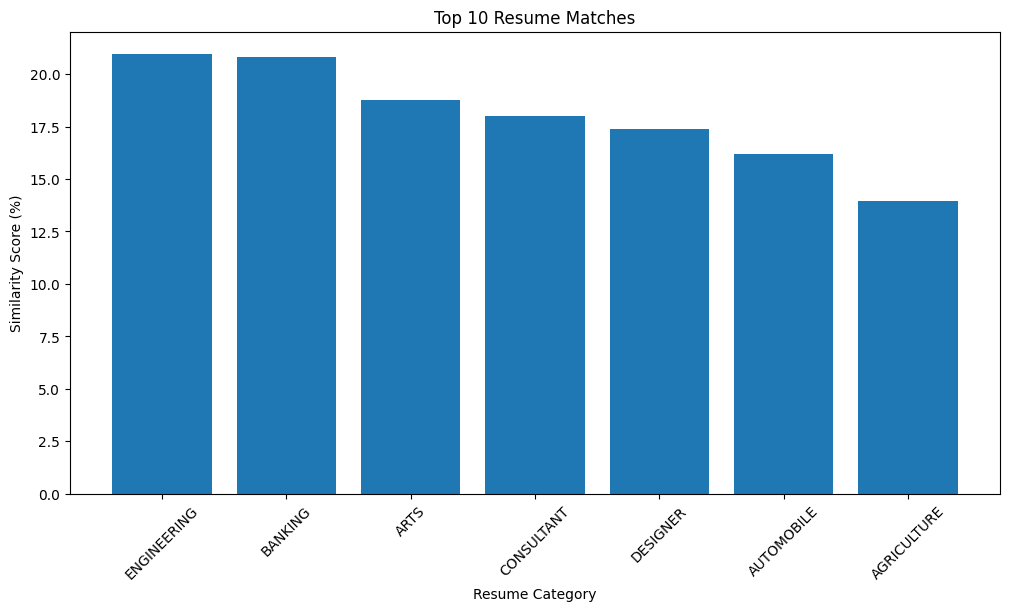

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_candidates["Category"],
    top_candidates["Match Score"]
)

plt.title("Top 10 Resume Matches")

plt.xlabel("Resume Category")

plt.ylabel("Similarity Score (%)")

plt.xticks(rotation=45)

plt.show()

In [51]:
import joblib

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("TF-IDF Vectorizer Saved Successfully!")

TF-IDF Vectorizer Saved Successfully!


In [52]:
best_resume = ranking.iloc[0]

print("Category:")
print(best_resume["Category"])

print("\nMatch Score:")
print(best_resume["Match Score"])

print("\nResume Preview:\n")
print(best_resume["Resume_str"][:1000])

Category:
ENGINEERING

Match Score:
20.98

Resume Preview:

engineering and quality technician       career overview    a highly experienced skilled graduate with analytics degree with a very good experience in sas web scraping sql predictive modelling and data visualization excellent ability in identifying data requirements for analysis data cleaning munging and model building ensures the organization uses it effectively to reach profit and growth objectives comfortable with data handling modeling and coding and have an appreciation of what makes sense from a business standpoint more than six years of experience working as a researcher data analyst and environmental science and technology instructor experience in sql data warehousing maintaining securing and stabilizing data layers and testing to identify data and product defects introduced in the system customer segmentation product positioning and mapping and conjoint analysis modelling design and implement statistical  predictive m

Part 4: Skill Extraction & Candidate Ranking

In [53]:
required_skills = [
    "python",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "sql",
    "pandas",
    "numpy",
    "scikit-learn",
    "git",
    "data analysis",
    "communication",
    "problem solving"
]

In [54]:
def extract_skills(resume):

    resume = resume.lower()

    matched = []

    for skill in required_skills:

        if skill in resume:

            matched.append(skill)

    return matched

In [55]:
df["Matched Skills"] = df["Clean_Resume"].apply(extract_skills)

df.head()

,ID,Category,Resume_str,Clean_Resume,Match Score,Matched Skills
0,16852973,HR,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...,1.55,[data analysis]
1,22323967,HR,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...,2.46,"[git, communication]"
2,33176873,HR,hr director summary over years exp...,hr director summary year experience recruiting...,0.00,[]
3,27018550,HR,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...,0.29,[communication]
4,17812897,HR,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...,0.96,[problem solving]


In [56]:
df["Matched Skill Count"] = df["Matched Skills"].apply(len)

df.head()

,ID,Category,Resume_str,Clean_Resume,Match Score,Matched Skills,Matched Skill Count
0,16852973,HR,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...,1.55,[data analysis],1
1,22323967,HR,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...,2.46,"[git, communication]",2
2,33176873,HR,hr director summary over years exp...,hr director summary year experience recruiting...,0.00,[],0
3,27018550,HR,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...,0.29,[communication],1
4,17812897,HR,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...,0.96,[problem solving],1


In [57]:
def missing_skills(matched):

    return list(
        set(required_skills) -
        set(matched)
    )

In [58]:
df["Missing Skills"] = df["Matched Skills"].apply(
    missing_skills
)

df.head()

,ID,Category,Resume_str,Clean_Resume,Match Score,Matched Skills,Matched Skill Count,Missing Skills
0,16852973,HR,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...,1.55,[data analysis],1,"[communication, sql, tensorflow, numpy, deep l..."
1,22323967,HR,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...,2.46,"[git, communication]",2,"[sql, tensorflow, numpy, deep learning, python..."
2,33176873,HR,hr director summary over years exp...,hr director summary year experience recruiting...,0.00,[],0,"[communication, sql, tensorflow, numpy, deep l..."
3,27018550,HR,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...,0.29,[communication],1,"[sql, tensorflow, numpy, deep learning, python..."
4,17812897,HR,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...,0.96,[problem solving],1,"[communication, sql, tensorflow, numpy, deep l..."


In [59]:
def recommendation(score):

    if score >= 80:

        return "⭐⭐⭐⭐⭐ Highly Recommended"

    elif score >= 60:

        return "⭐⭐⭐⭐ Recommended"

    elif score >= 40:

        return "⭐⭐⭐ Consider"

    else:

        return "⭐ Not Recommended"

In [60]:
df["Recommendation"] = df["Match Score"].apply(
    recommendation
)

df.head()

,ID,Category,Resume_str,Clean_Resume,Match Score,Matched Skills,Matched Skill Count,Missing Skills,Recommendation
0,16852973,HR,hr administratormarketing associate\n\nhr admi...,hr administratormarketing associate hr adminis...,1.55,[data analysis],1,"[communication, sql, tensorflow, numpy, deep l...",⭐ Not Recommended
1,22323967,HR,hr specialist us hr operations summary ...,hr specialist u hr operation summary versatile...,2.46,"[git, communication]",2,"[sql, tensorflow, numpy, deep learning, python...",⭐ Not Recommended
2,33176873,HR,hr director summary over years exp...,hr director summary year experience recruiting...,0.00,[],0,"[communication, sql, tensorflow, numpy, deep l...",⭐ Not Recommended
3,27018550,HR,hr specialist summary dedicated drive...,hr specialist summary dedicated driven dynamic...,0.29,[communication],1,"[sql, tensorflow, numpy, deep learning, python...",⭐ Not Recommended
4,17812897,HR,hr manager skill highlights ...,hr manager skill highlight hr skill hr departm...,0.96,[problem solving],1,"[communication, sql, tensorflow, numpy, deep l...",⭐ Not Recommended


In [61]:
final_ranking = df.sort_values(
    by="Match Score",
    ascending=False
)

final_ranking.head(10)

,ID,Category,Resume_str,Clean_Resume,Match Score,Matched Skills,Matched Skill Count,Missing Skills,Recommendation
1762,12011623,ENGINEERING,engineering and quality technician caree...,engineering quality technician career overview...,20.98,"[python, machine learning, sql, data analysis]",4,"[communication, tensorflow, numpy, deep learni...",⭐ Not Recommended
2153,34953092,BANKING,corporate banking assistant intern o...,corporate banking assistant intern objective d...,20.83,"[python, machine learning, sql]",3,"[communication, tensorflow, numpy, deep learni...",⭐ Not Recommended
2293,26069113,ARTS,software engineer profile experience...,software engineer profile experienced software...,18.78,[],0,"[communication, sql, tensorflow, numpy, deep l...",⭐ Not Recommended
2291,12777487,ARTS,online learning coordinator program training ...,online learning coordinator program training s...,18.32,[],0,"[communication, sql, tensorflow, numpy, deep l...",⭐ Not Recommended
1218,21156767,CONSULTANT,pavithra shetty summary custome...,pavithra shetty summary customeroriented princ...,18.01,"[python, machine learning, sql, data analysis]",4,"[communication, tensorflow, numpy, deep learni...",⭐ Not Recommended
194,18835363,DESIGNER,program manager designer professional...,program manager designer professional summary ...,17.38,[],0,"[communication, sql, tensorflow, numpy, deep l...",⭐ Not Recommended
1339,18448085,AUTOMOBILE,data analyst professional summary ind...,data analyst professional summary industrial s...,16.21,"[python, sql, numpy, data analysis, problem so...",5,"[communication, tensorflow, deep learning, pyt...",⭐ Not Recommended
1142,30863060,CONSULTANT,consultant summary college graduate w...,consultant summary college graduate interest i...,15.93,"[sql, communication]",2,"[tensorflow, numpy, deep learning, python, pro...",⭐ Not Recommended
1348,22946204,AUTOMOBILE,highlights prog languages c ...,highlight prog language c yr python yr java yr...,14.75,"[python, machine learning, sql, data analysis]",4,"[communication, tensorflow, numpy, deep learni...",⭐ Not Recommended
926,62994611,AGRICULTURE,software developer professional summar...,software developer professional summary enthus...,13.96,"[python, tensorflow, sql, communication]",4,"[numpy, deep learning, problem solving, pytorc...",⭐ Not Recommended


In [62]:
top_candidate = final_ranking.iloc[0]

print("="*60)

print("TOP CANDIDATE")

print("="*60)

print("Category:")
print(top_candidate["Category"])

print()

print("Match Score:")
print(top_candidate["Match Score"], "%")

print()

print("Matched Skills:")
print(top_candidate["Matched Skills"])

print()

print("Missing Skills:")
print(top_candidate["Missing Skills"])

print()

print("Recommendation:")
print(top_candidate["Recommendation"])

TOP CANDIDATE
Category:
ENGINEERING

Match Score:
20.98 %

Matched Skills:
['python', 'machine learning', 'sql', 'data analysis']

Missing Skills:
['communication', 'tensorflow', 'numpy', 'deep learning', 'problem solving', 'pytorch', 'pandas', 'git', 'scikit-learn']

Recommendation:
⭐ Not Recommended


In [63]:
hr_report = final_ranking[
    [
        "Category",
        "Match Score",
        "Matched Skill Count",
        "Recommendation"
    ]
]

hr_report.head(20)

,Category,Match Score,Matched Skill Count,Recommendation
1762,ENGINEERING,20.98,4,⭐ Not Recommended
2153,BANKING,20.83,3,⭐ Not Recommended
2293,ARTS,18.78,0,⭐ Not Recommended
2291,ARTS,18.32,0,⭐ Not Recommended
1218,CONSULTANT,18.01,4,⭐ Not Recommended
194,DESIGNER,17.38,0,⭐ Not Recommended
1339,AUTOMOBILE,16.21,5,⭐ Not Recommended
1142,CONSULTANT,15.93,2,⭐ Not Recommended
1348,AUTOMOBILE,14.75,4,⭐ Not Recommended
926,AGRICULTURE,13.96,4,⭐ Not Recommended


In [64]:
hr_report.to_csv(
    "Candidate_Ranking_Report.csv",
    index=False
)

print("Report Saved Successfully!")

Report Saved Successfully!


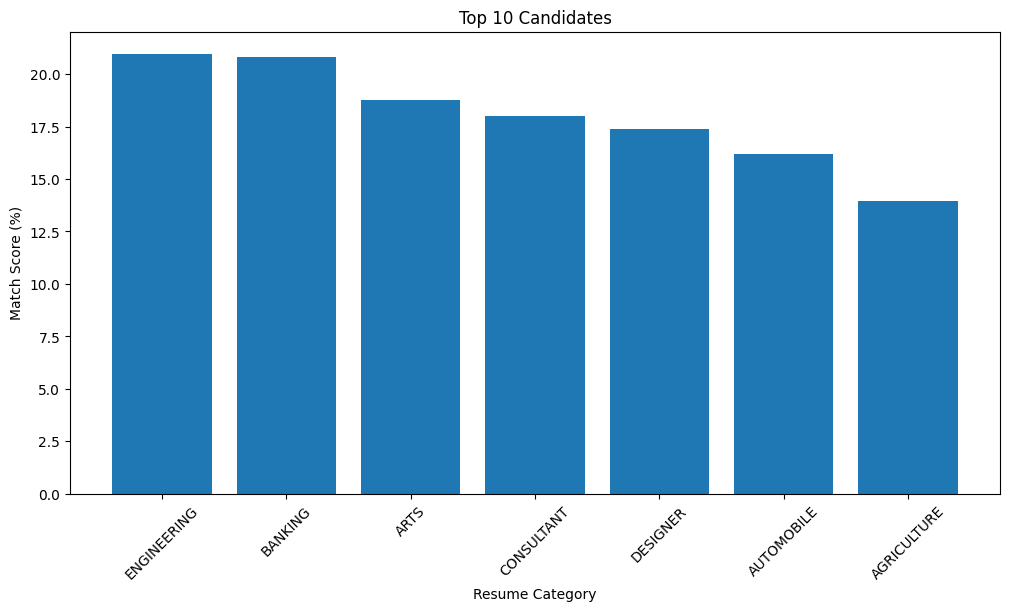

In [65]:
plt.figure(figsize=(12,6))

top10 = final_ranking.head(10)

plt.bar(
    top10["Category"],
    top10["Match Score"]
)

plt.title("Top 10 Candidates")

plt.xlabel("Resume Category")

plt.ylabel("Match Score (%)")

plt.xticks(rotation=45)

plt.show()

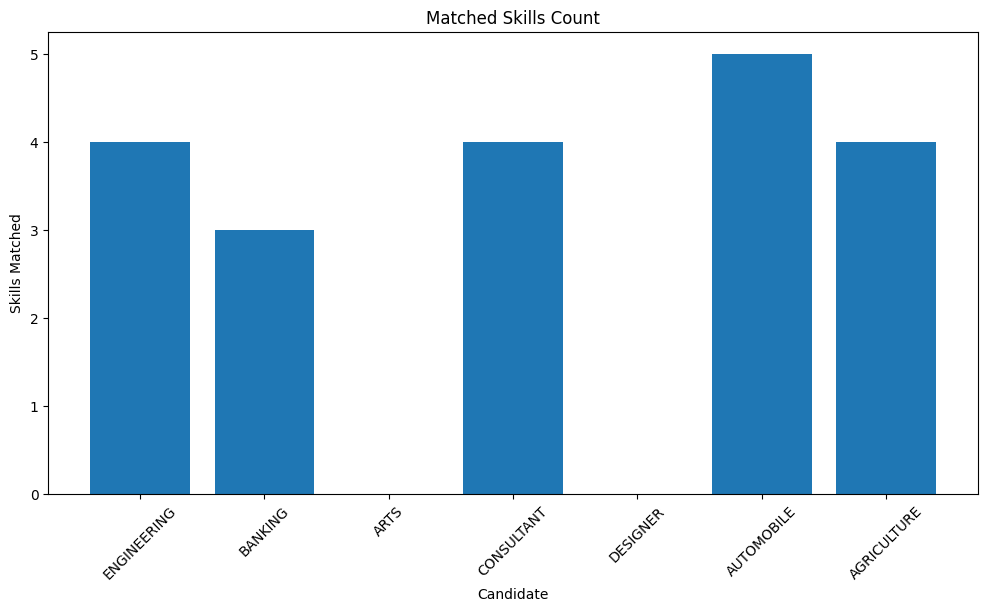

In [66]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["Category"],
    top10["Matched Skill Count"]
)

plt.title("Matched Skills Count")

plt.xlabel("Candidate")

plt.ylabel("Skills Matched")

plt.xticks(rotation=45)

plt.show()

Part 5: Interactive Resume Screening System & Final Evaluation

In [67]:
def screen_resume(resume_text):

    # Convert to lowercase
    resume_text = resume_text.lower()

    # Remove punctuation
    resume_text = re.sub(r"[^\w\s]", "", resume_text)

    # Remove numbers
    resume_text = re.sub(r"\d+", "", resume_text)

    # Remove stopwords
    words = resume_text.split()

    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    cleaned_resume = " ".join(words)

    # Convert to TF-IDF
    resume_vector = tfidf.transform([cleaned_resume])

    # Convert Job Description
    job_vector = tfidf.transform([job_description])

    # Similarity Score
    similarity = cosine_similarity(
        job_vector,
        resume_vector
    )[0][0]

    score = round(similarity * 100, 2)

    # Extract Skills
    matched = extract_skills(cleaned_resume)

    missing = list(
        set(required_skills) -
        set(matched)
    )

    recommendation_text = recommendation(score)

    print("="*60)
    print("AI Resume Screening Report")
    print("="*60)

    print("\nJob Role:")
    print("AI Engineer")

    print("\nMatch Score:")
    print(score,"%")

    print("\nMatched Skills:")
    for skill in matched:
        print("✔", skill)

    print("\nMissing Skills:")
    for skill in missing:
        print("✖", skill)

    print("\nRecommendation:")
    print(recommendation_text)

In [68]:
resume = """
Python Developer with 3 years of experience in Machine Learning,
Deep Learning, TensorFlow, SQL, Pandas,
NumPy, Git and Data Analysis.
"""

screen_resume(resume)

AI Resume Screening Report

Job Role:
AI Engineer

Match Score:
71.23 %

Matched Skills:
✔ python
✔ machine learning
✔ deep learning
✔ tensorflow
✔ sql
✔ numpy
✔ git
✔ data analysis

Missing Skills:
✖ communication
✖ problem solving
✖ pytorch
✖ pandas
✖ scikit-learn

Recommendation:
⭐⭐⭐⭐ Recommended


In [69]:
resume = """
Experienced HR Manager with Recruitment,
Payroll Management,
Communication and Leadership Skills.
"""

screen_resume(resume)

AI Resume Screening Report

Job Role:
AI Engineer

Match Score:
2.47 %

Matched Skills:
✔ communication

Missing Skills:
✖ sql
✖ tensorflow
✖ numpy
✖ deep learning
✖ python
✖ problem solving
✖ pytorch
✖ machine learning
✖ pandas
✖ data analysis
✖ git
✖ scikit-learn

Recommendation:
⭐ Not Recommended


In [70]:
resume = """
Data Scientist with Python,
Machine Learning,
Scikit-learn,
SQL,
TensorFlow,
Pandas,
NumPy,
Git,
Problem Solving.
"""

screen_resume(resume)

AI Resume Screening Report

Job Role:
AI Engineer

Match Score:
56.27 %

Matched Skills:
✔ python
✔ machine learning
✔ tensorflow
✔ sql
✔ numpy
✔ git
✔ problem solving

Missing Skills:
✖ communication
✖ deep learning
✖ pytorch
✖ pandas
✖ data analysis
✖ scikit-learn

Recommendation:
⭐⭐⭐ Consider


In [72]:
final_ranking.to_csv(
    "Final_Candidate_Ranking.csv",
    index=False
)

print("Ranking Saved Successfully!")

Ranking Saved Successfully!


In [73]:
import joblib

joblib.dump(
    tfidf,
    "tfidf_vectorizer.pkl"
)

print("TF-IDF Model Saved Successfully!")

TF-IDF Model Saved Successfully!


In [74]:
top5 = final_ranking[
    [
        "Category",
        "Match Score",
        "Recommendation"
    ]
].head()

top5

,Category,Match Score,Recommendation
1762,ENGINEERING,20.98,⭐ Not Recommended
2153,BANKING,20.83,⭐ Not Recommended
2293,ARTS,18.78,⭐ Not Recommended
2291,ARTS,18.32,⭐ Not Recommended
1218,CONSULTANT,18.01,⭐ Not Recommended


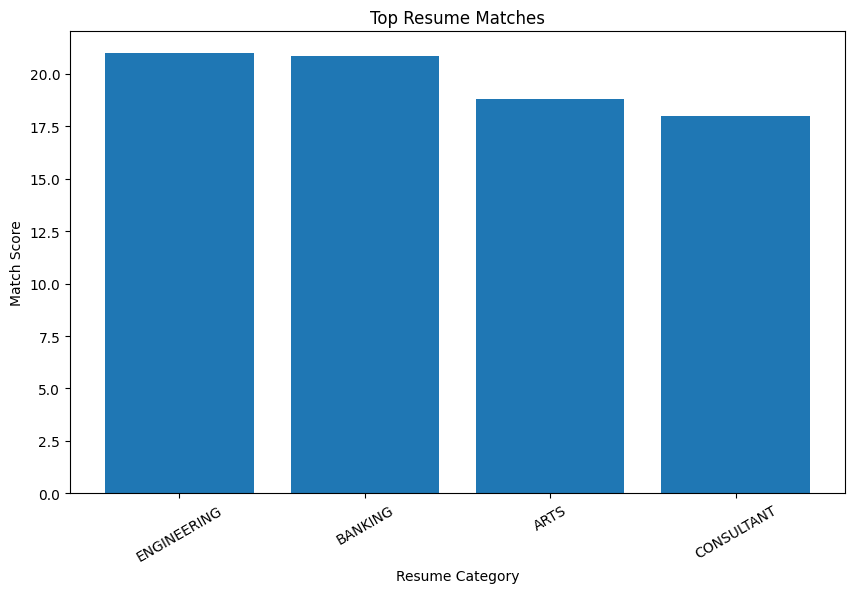

In [75]:
plt.figure(figsize=(10,6))

plt.bar(
    top5["Category"],
    top5["Match Score"]
)

plt.title("Top Resume Matches")

plt.xlabel("Resume Category")

plt.ylabel("Match Score")

plt.xticks(rotation=30)

plt.show()

# Business Insights

## AI Resume Screening System

This project demonstrates how Natural Language Processing (NLP) can automate the initial screening of resumes by comparing candidate profiles with job requirements.

### Key Features

- Resume text preprocessing
- Skill extraction
- TF-IDF based similarity scoring
- Candidate ranking
- Skill gap identification
- Interactive resume screening

### Benefits

- Reduces manual resume screening time
- Improves consistency in candidate evaluation
- Identifies missing skills quickly
- Helps recruiters shortlist suitable candidates efficiently

### Future Improvements

- PDF resume parsing
- Support for multiple job roles
- Integration with HR systems
- Use transformer-based models like BERT
- Deploy as a Streamlit web application